# Exploring entrepreneurship in France (2012–2024)

I recently came across a video by *HugoDécrypte* mentioning that around **40% of new entrepreneurs in France are under 30 years old**.  
That caught my attention and it made me wonder how the data really reflects this trend and how entrepreneurship in France has evolved over the years.

This project aims to explore **business creation trends in France** using **INSEE’s public data** on new businesses between 2012 and 2024.  
The goal is to understand:
- how entrepreneurship in France has evolved over time,  
- which regions and sectors drive this growth,  
- how age, gender, and legal form shape the entrepreneurial landscape.

Through this exploratory analysis, we’ll visualize and interpret how entrepreneurship in France has transformed over the last decade.


# Installation and imports

In [1]:
!pip install --upgrade pip
!pip install pandas numpy matplotlib seaborn plotly scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Imports des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="muted")


# Data source 
This analysis uses data from **INSEE (Institut National de la Statistique et des Études Économiques)** on **business creations in France**.  
Data available via https://www.data.gouv.fr/datasets/creations-dentreprises-individuelles-unites-legales/

In [106]:
# Load INSEE data (make sure both CSVs are in the 'data' folder)

data_path = "data/DS_SIDE_CREA_EI_2024_data.csv"
meta_path = "data/DS_SIDE_CREA_EI_2024_metadata.csv"

data = pd.read_csv(data_path, sep=";", encoding="utf-8")
meta = pd.read_csv(meta_path, sep=";", encoding="utf-8")

print("✅ Data loaded successfully")
print(f"Data shape: {data.shape}")
print(f"Metadata shape: {meta.shape}")

✅ Data loaded successfully
Data shape: (561600, 10)
Metadata shape: (162, 4)


# Understanding the data set

The dataset provides a multidimensional view of entrepreneurship by sector, region, age, gender, and legal form, between 2012 and 2024.

**Numeric Variables :**
1. **OBS_VALUE :**
Represents the number of new *entreprises individuelles* (individual businesses) registered during a given year, for a specific combination of characteristics (region, sector, age group, gender, legal form).
2. **TIME_PERIOD :** 
Indicates the year the observation refers to (2012–2024).

**Categrical Variables :**
1. **ACTIVITY :**
Based on the NAF/APE classification (INSEE).
2. **AGE :**
Age group of the business creator
3. **SEX** :
Gender of the business creator  
4. **LEGAL_FORM :**
Legal form of the enterprise  
   - `MICRO` → Micro-entrepreneur  
   - `ENTIND_X_MICRO` → Entreprise individuelle hors micro  
   - `_T` → Total (both categories)
5. **GEO :**
Geographic code that identifies the location corresponding to the observation.  
   - `FRANCE` → Whole country  
   - `REG` → Region-level codes
   - `DEP` → Department-level codes (e.g., 75 = Paris, 13 = Bouches-du-Rhône)
6. **GEO_OBJECT :**
Geographic level of aggregation that specifies whether the data refers to France, a region, or a department.
7. **SIDE_MEASURE :**
Measure type which is always `BURE`, representing *Nombre de nouvelles unités légales enregistrées* (newly created legal units).
8. **FREQ :**
Frequency of observation which is always `A` for Annual frequency.

The data includes a metadata dictionary (`_metadata.csv`).

In [4]:
data.head()

,ACTIVITY,AGE,FREQ,GEO,GEO_OBJECT,LEGAL_FORM,SEX,SIDE_MEASURE,TIME_PERIOD,OBS_VALUE
0,N,_T,A,F,FRANCE,_T,F,BURE,2024,39587
1,S,_T,A,F,FRANCE,_T,_T,BURE,2023,74413
2,Q,_T,A,F,FRANCE,ENTIND_X_MICRO,_T,BURE,2024,28804
3,G,_T,A,F,FRANCE,_T,M,BURE,2019,57364
4,S,_T,A,F,FRANCE,_T,_T,BURE,2019,46516


In [5]:
data_columns = list(data.columns)
for col in data_columns:
    print(f"{col} :", data[col].unique())

ACTIVITY : ['N' 'S' 'Q' 'G' 'BTSXO' 'F' 'L' 'R' 'BE' 'I' 'J' 'P' 'K' 'H' 'M']
AGE : ['_T' 'Y50T59' 'Y_LT30' 'Y30T39' 'Y_GE60' 'Y40T49']
FREQ : ['A']
GEO : ['F' '10' '44' '74' '972' '29' '77' '23' '33' '45' '82' '86' '11' '66'
 '05' '03' '69' '87' '24' '67' '974' '31' '85' '83' '32' '52' '37' '84'
 '93' '02' '60' '57' '61' '65' '54' '88' '06' '27' '07' '63' '58' '64'
 '36' '973' '49' '15' '09' '80' '12' '89' '42' '08' '78' '43' '17' '30'
 '59' '22' '72' '01' '14' '41' '56' '94' '75' '971' '25' '28' '40' '90'
 '46' '76' '79' '51' '70' '21' '2B' '2A' '81' '34' '976' '50' '71' '91'
 '39' '04' '73' '62' '13' '16' '92' '19' '47' '35' '48' '55' '53' '95'
 '18' '26' '68' '38']
GEO_OBJECT : ['FRANCE' 'DEP' 'REG']
LEGAL_FORM : ['_T' 'ENTIND_X_MICRO' 'MICRO']
SEX : ['F' '_T' 'M']
SIDE_MEASURE : ['BURE']
TIME_PERIOD : [2024 2023 2019 2014 2015 2013 2017 2012 2022 2016 2018 2020 2021]
OBS_VALUE : [39587 74413 28804 ... 71328  4465     0]


In [6]:
data.info() 
data.shape

print("\nNumber of rows:", len(data))
print("\nNumber of columns:", len(data.columns))
print("\nTime coverage:", data["TIME_PERIOD"].min(), "to", data["TIME_PERIOD"].max())
print("\nGeographic levels:")
print(data["GEO_OBJECT"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561600 entries, 0 to 561599
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   ACTIVITY      561600 non-null  object
 1   AGE           561600 non-null  object
 2   FREQ          561600 non-null  object
 3   GEO           561600 non-null  object
 4   GEO_OBJECT    561600 non-null  object
 5   LEGAL_FORM    561600 non-null  object
 6   SEX           561600 non-null  object
 7   SIDE_MEASURE  561600 non-null  object
 8   TIME_PERIOD   561600 non-null  int64 
 9   OBS_VALUE     561600 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 42.8+ MB

Number of rows: 561600

Number of columns: 10

Time coverage: 2012 to 2024

Geographic levels:
GEO_OBJECT
DEP       472680
REG        84240
FRANCE      4680
Name: count, dtype: int64


## Missing values and duplicates

In [7]:
print("\nMissing values per column:")
print(data.isna().sum())

dup_keys = ["TIME_PERIOD","GEO","GEO_OBJECT","ACTIVITY","SEX","AGE","LEGAL_FORM","SIDE_MEASURE","FREQ"]
print("\nDuplicate rows (same keys):", data.duplicated(dup_keys).sum())


Missing values per column:
ACTIVITY        0
AGE             0
FREQ            0
GEO             0
GEO_OBJECT      0
LEGAL_FORM      0
SEX             0
SIDE_MEASURE    0
TIME_PERIOD     0
OBS_VALUE       0
dtype: int64

Duplicate rows (same keys): 0


## Descriptive statistics

In [8]:
print("\nNumerical summary:")
print(data.describe())

print("\nOBS_VALUE by geographic level:")
print(data.groupby("GEO_OBJECT")["OBS_VALUE"].describe())


Numerical summary:
         TIME_PERIOD      OBS_VALUE
count  561600.000000  561600.000000
mean     2018.000000     319.051282
std         3.741661    5607.190489
min      2012.000000       0.000000
25%      2015.000000       0.000000
50%      2018.000000       0.000000
75%      2021.000000       0.000000
max      2024.000000  826674.000000

OBS_VALUE by geographic level:
               count          mean           std   min     25%     50%  \
GEO_OBJECT                                                               
DEP         472680.0     94.767708    815.019266   0.0     0.0     0.0   
FRANCE        4680.0  19143.076923  54504.721111  17.0  1342.5  4921.0   
REG          84240.0    531.752137   4566.845820   0.0     0.0     0.0   

                75%       max  
GEO_OBJECT                     
DEP             0.0   59716.0  
FRANCE      14629.5  826674.0  
REG             0.0  215951.0  


## Meta data
Let's use metadata to add readable labels

In [9]:
meta.head()

,COD_VAR,LIB_VAR,COD_MOD,LIB_MOD
0,ACTIVITY,Activité économique,BE,"Industrie manufacturière, industries extractiv..."
1,ACTIVITY,Activité économique,F,Construction
2,ACTIVITY,Activité économique,G,Commerce ; réparation d'automobiles et de moto...
3,ACTIVITY,Activité économique,H,Transports et entreposage
4,ACTIVITY,Activité économique,I,Hébergement et restauration


In [10]:
# Create mapping dictionaries from metadata
# For each group COD_VAR, we take the columns COD_MOD and LIB_MOD and zip them together to make a dictionary.
label_dicts = (
    meta.groupby("COD_VAR", group_keys=False)
    .apply(lambda x: dict(zip(x["COD_MOD"], x["LIB_MOD"])), include_groups=False)
    .to_dict()
)

In [11]:
# Apply the mappings to the data
for var, mapping in label_dicts.items():
    if var in data.columns:
        data[var + "_LABEL"] = data[var].map(mapping)

data.head()

,ACTIVITY,AGE,FREQ,GEO,GEO_OBJECT,LEGAL_FORM,SEX,SIDE_MEASURE,TIME_PERIOD,OBS_VALUE,ACTIVITY_LABEL,AGE_LABEL,FREQ_LABEL,GEO_LABEL,LEGAL_FORM_LABEL,SEX_LABEL,SIDE_MEASURE_LABEL,TIME_PERIOD_LABEL
0,N,_T,A,F,FRANCE,_T,F,BURE,2024,39587,Activités de services administratifs et de sou...,Total,Annuel,France,Total,Femme,Nombre de nouvelles unités légales enregistrées,NaN
1,S,_T,A,F,FRANCE,_T,_T,BURE,2023,74413,Autres activités de services,Total,Annuel,France,Total,Total,Nombre de nouvelles unités légales enregistrées,NaN
2,Q,_T,A,F,FRANCE,ENTIND_X_MICRO,_T,BURE,2024,28804,Santé humaine et action sociale,Total,Annuel,France,Entreprises individuelles hors micro-entrepren...,Total,Nombre de nouvelles unités légales enregistrées,NaN
3,G,_T,A,F,FRANCE,_T,M,BURE,2019,57364,Commerce ; réparation d'automobiles et de moto...,Total,Annuel,France,Total,Homme,Nombre de nouvelles unités légales enregistrées,NaN
4,S,_T,A,F,FRANCE,_T,_T,BURE,2019,46516,Autres activités de services,Total,Annuel,France,Total,Total,Nombre de nouvelles unités légales enregistrées,NaN


In [12]:
# Keep a clean version of the data
data.to_csv("clean_data.csv", index=False)

# Exploratory Data Analysis

### [Overview of main trends](#overview)  
- [Evolution of business creations over time](#evolution-of-business-creations-over-time)
- [Top regions by number of creations (latest year)](#region-over-time)
- [Sectoral distribution](#sector)

### [Demographic insights](#demographic)  
- [Gender distribution (national level)](#gender)  
- [Age distribution](#age)  

### [Legal form](#legal)  
- [Legal form distribution over time](#legal_dist)  

## Overview of main trends <a id="overview"></a>

### Evolution of business creations over time <a id="evolution-of-business-creations-over-time"></a>


Between **2012 and 2024**, the number of new businesses created in France has **roughly doubled**, increasing from around **800,000** to over **1.6 million**.  

After a relatively stable period between **2012 and 2016**, the strong acceleration observed from **2017 onward** may be associated with the **expansion of the micro-entrepreneur regime**, improved **digital infrastructure**, and **simplified administrative procedures**.  

Although the **COVID-19 pandemic in 2020** might have constrained economic activity, business creation remained resilient and continued to grow in subsequent years.  
This sustained increase could indicate a **shift toward more flexible, independent, and digitally oriented work models**, showing how entrepreneurship adapts to evolving economic and social conditions in France.


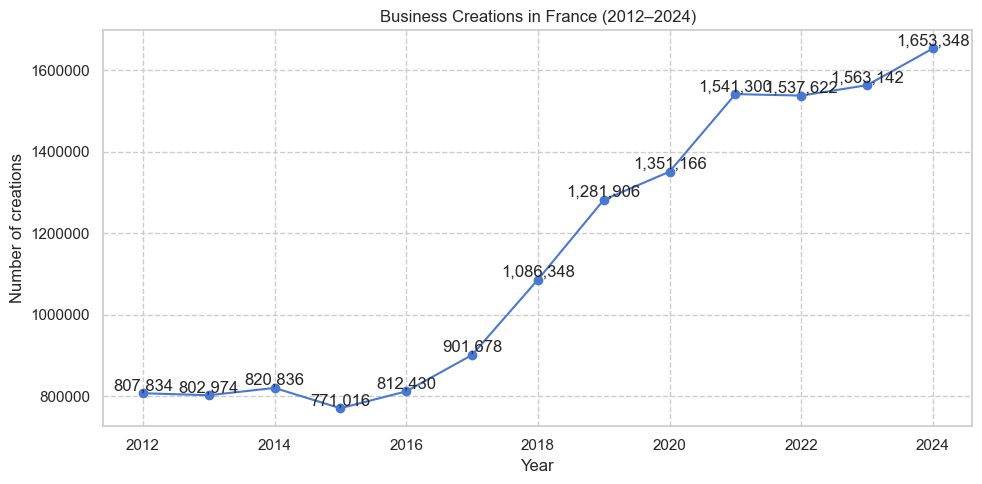

In [50]:
# Focus on cleaned data
data = data.copy()

fr = data[
    (data["GEO_OBJECT"] == "FRANCE")
    & (data["AGE"] == "_T")
    & (data["SEX"] == "_T")
    & (data["LEGAL_FORM"] == "_T")
]

# Group by year and sum all values
trend = fr.groupby("TIME_PERIOD", as_index=False)["OBS_VALUE"].sum()

# Simple line plot
plt.figure(figsize=(10,5))
plt.plot(trend["TIME_PERIOD"], trend["OBS_VALUE"], marker="o")

# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{int(x)}"))

# Add data labels
for x, y in zip(trend["TIME_PERIOD"], trend["OBS_VALUE"]):
    plt.text(x, y, f"{y:,}", ha="center", va="bottom")

# Titles and labels
plt.title("Business Creations in France (2012–2024)")
plt.xlabel("Year")
plt.ylabel("Number of creations")
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()


### Top regions by number of creations (latest year) <a id="region-over-time"></a>

In 2024, **Île-de-France** stands out as the dominant region, accounting for **215 951 business creations**.
This may reflect its economic concentration, population density, and strong service-sector base, particularly in digital and professional activities.  

Regions such as **Auvergne-Rhône-Alpes**, **Occitanie**, and **Provence-Alpes-Côte d’Azur** also show high levels of entrepreneurship.
By contrast, regions with smaller populations, like **Bretagne** or **Normandie**, record lower absolute numbers.

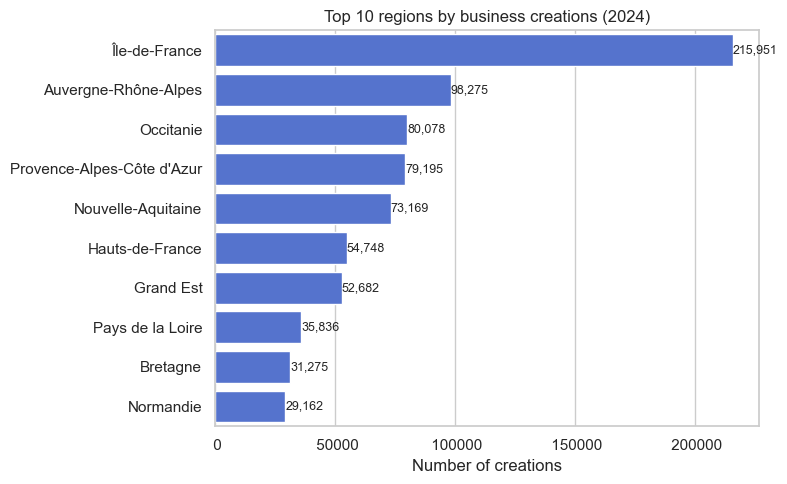

In [51]:
import matplotlib.ticker as ticker 

latest_year = data["TIME_PERIOD"].max()

region_data = data[
    (data["GEO_OBJECT"] == "REG")
    & (data["AGE"] == "_T")
    & (data["SEX"] == "_T")
    & (data["LEGAL_FORM"] == "_T")
    & (data["TIME_PERIOD"] == latest_year)
]

top_regions = (
    region_data.groupby("GEO_LABEL", as_index=False)["OBS_VALUE"].sum()
    .sort_values("OBS_VALUE", ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
ax = sns.barplot(data=top_regions, y="GEO_LABEL", x="OBS_VALUE", color="royalblue")

# Add labels on bars
for i, v in enumerate(top_regions["OBS_VALUE"]):
    plt.text(v, i, f"{v:,}", va='center')

# Fix x-axis formatting (no scientific notation)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x: .0f}"))

plt.title(f"Top 10 regions by business creations ({latest_year})")
plt.xlabel("Number of creations")
plt.ylabel("")
plt.tight_layout()
plt.show()


### Sectoral distribution <a id="sector"></a>

The concentration of new businesses in commerce, administrative services, and construction may suggest that **sectors requiring low initial investment or specific expertise attract more entrepreneurs**.  
The relatively smaller share of industrial and digital sectors could indicate **higher entry barriers** or **slower adaptation to independent work models**.  
It may also reflect how the **micro-entrepreneur regime** primarily supports **service-oriented and flexible activities**.

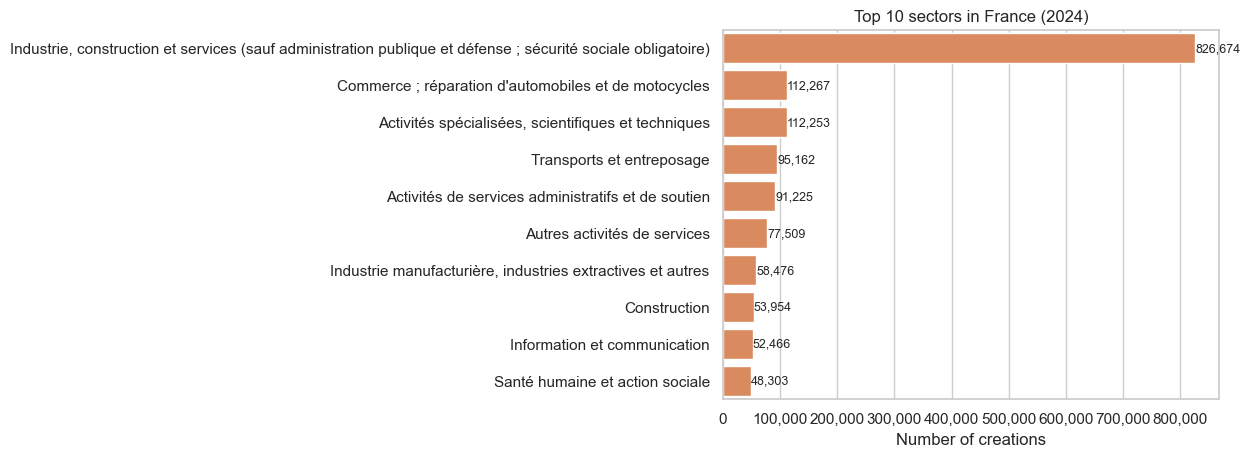

In [67]:
sector_data = data[
    (data["GEO_OBJECT"] == "FRANCE")
    & (data["AGE"] == "_T")
    & (data["SEX"] == "_T")
    & (data["LEGAL_FORM"] == "_T")
    & (data["TIME_PERIOD"] == latest_year)
]

top_sectors = (sector_data.groupby("ACTIVITY_LABEL", as_index=False)["OBS_VALUE"].sum()
               .sort_values("OBS_VALUE", ascending=False)
              .head(10))

ax = sns.barplot(data=top_sectors, y="ACTIVITY_LABEL", x="OBS_VALUE")

# Add labels on bars
for i, v in enumerate(top_sectors["OBS_VALUE"]):
    plt.text(v, i, f"{v:,}", va='center', fontsize=9)

# Fix x-axis formatting (no scientific notation)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

sns.barplot(data=top_sectors.head(10), x="OBS_VALUE", y="ACTIVITY_LABEL")
plt.title(f"Top 10 sectors in France ({latest_year})")
plt.xlabel("Number of creations")
plt.ylabel("")
plt.show()


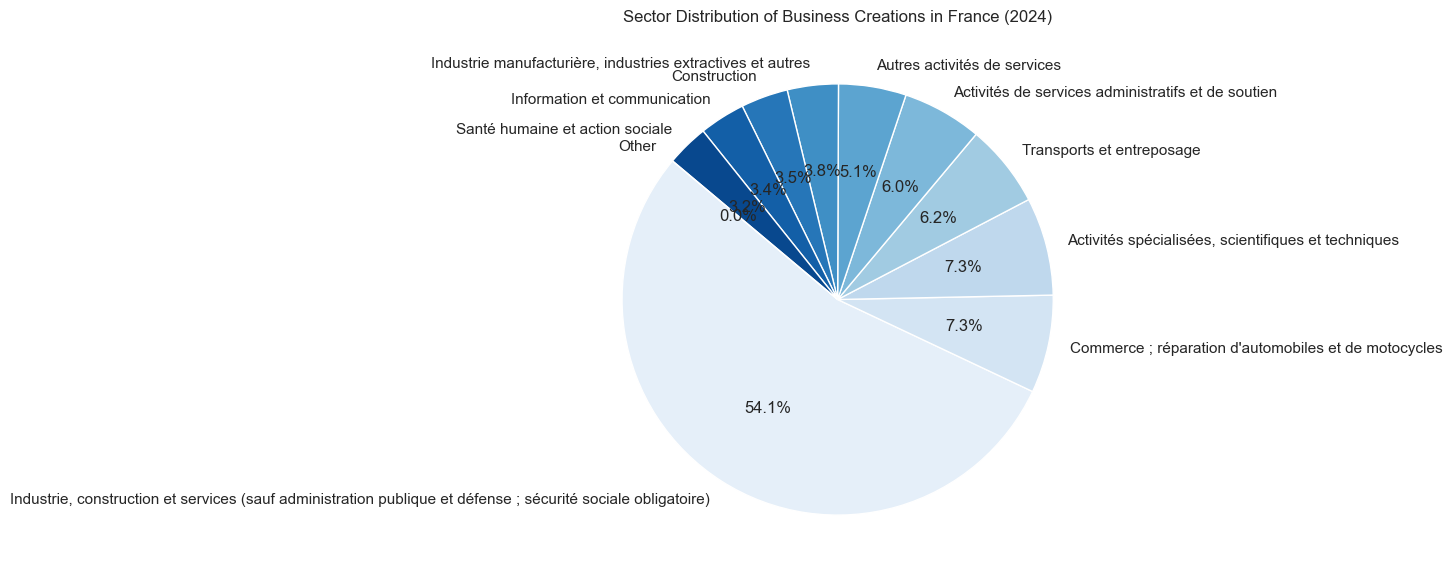

,ACTIVITY_LABEL,OBS_VALUE
11,"Industrie, construction et services (sauf admi...",4960044
6,Commerce ; réparation d'automobiles et de moto...,673602
3,"Activités spécialisées, scientifiques et techn...",673518
14,Transports et entreposage,570972
0,Activités de services administratifs et de sou...,547350
5,Autres activités de services,465054
10,"Industrie manufacturière, industries extractiv...",350856
7,Construction,323724
12,Information et communication,314796
13,Santé humaine et action sociale,289818


In [45]:
# Pie chart of sector distribution (latest year)
plt.figure(figsize=(7,7))

others_sum = top_sectors["OBS_VALUE"].iloc[10:].sum()

# Append "Other" category
top10_other = pd.concat([top_sectors, pd.DataFrame({"ACTIVITY_LABEL": ["Other"], "OBS_VALUE": [others_sum]})])

plt.pie(
    top10_other["OBS_VALUE"],
    labels=top10_other["ACTIVITY_LABEL"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Blues", n_colors=10)
)

plt.title(f"Sector Distribution of Business Creations in France ({latest_year})")

plt.show()

top_sectors

## Demographic insight <a id="demographic"></a>

### Gender distribution (national level) <a id="gender"></a>

Between 2012 and 2024, both male and female entrepreneurship in France show a clear upward trend, with total business creations roughly **doubling** over the period.  
While **men consistently create more businesses** than women, the **gap appears to be narrowing** slightly, particularly after **2017**.  


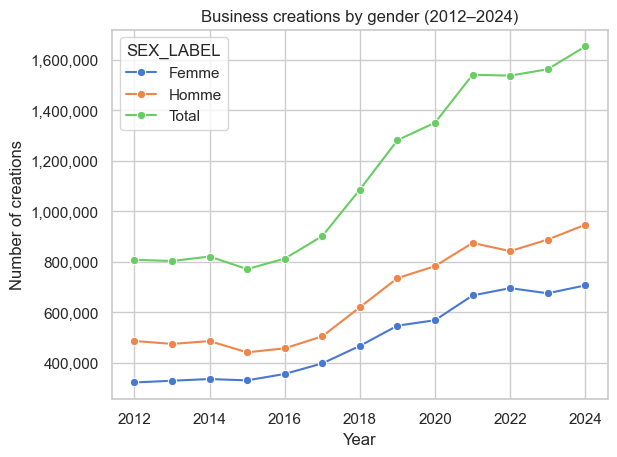

In [68]:
gender = data[
    (data["GEO_OBJECT"] == "FRANCE")
    & (data["AGE"] == "_T")
    & (data["LEGAL_FORM"] == "_T")
]

gender_trend = (gender.groupby(["TIME_PERIOD", "SEX_LABEL"], as_index=False)["OBS_VALUE"].sum())

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

sns.lineplot(data=gender_trend, x="TIME_PERIOD", y="OBS_VALUE", hue="SEX_LABEL", marker="o")
plt.title("Business creations by gender (2012–2024)")
plt.xlabel("Year")
plt.ylabel("Number of creations")
plt.show()


In [79]:

# Pivot to have one column per gender
gender_df = gender_trend.pivot(index="TIME_PERIOD", columns="SEX_LABEL", values="OBS_VALUE").fillna(0)

# Calculate total and percentage
gender_df["% Femme"] = (gender_df["Femme"] / gender_df["Total"] * 100).round(1)
gender_df["% Homme"] = (gender_df["Homme"] / gender_df["Total"] * 100).round(1)

# Display simple DataFrame
gender_df[["Femme", "Homme", "Total", "% Femme", "% Homme"]]


SEX_LABEL,Femme,Homme,Total,% Femme,% Homme
TIME_PERIOD,,,,,
2012,321730,486104,807834,39.8,60.2
2013,328504,474470,802974,40.9,59.1
2014,335236,485600,820836,40.8,59.2
2015,329986,441030,771016,42.8,57.2
2016,355438,456992,812430,43.7,56.3
2017,397250,504428,901678,44.1,55.9
2018,466530,619818,1086348,42.9,57.1
2019,546804,735102,1281906,42.7,57.3
2020,568308,782858,1351166,42.1,57.9


### Age distribution <a id="age"></a>

Entrepreneurship in France appears to be **driven primarily by younger age groups**, with **individuals under 30** representing nearly **40% of new business creations** in 2024. Those aged between 30–39 also make up a significant portion.

This pattern may indicate that **younger generations are increasingly attracted to entrepreneurship**, possibly due to:
- the flexibility offered by the micro-entrepreneur regime,
- the rise of digital platforms which facilitates self-employment,
- and a cultural shift toward autonomy and alternative career paths.

Over time, all age groups show growth in business creation, but the **under-30 and 30–39 brackets** shows the strongest increase.   
This may suggest that entrepreneurship is becoming an earlier career choice, contrasting with older generations who tend to enter entrepreneurship later or less frequently.

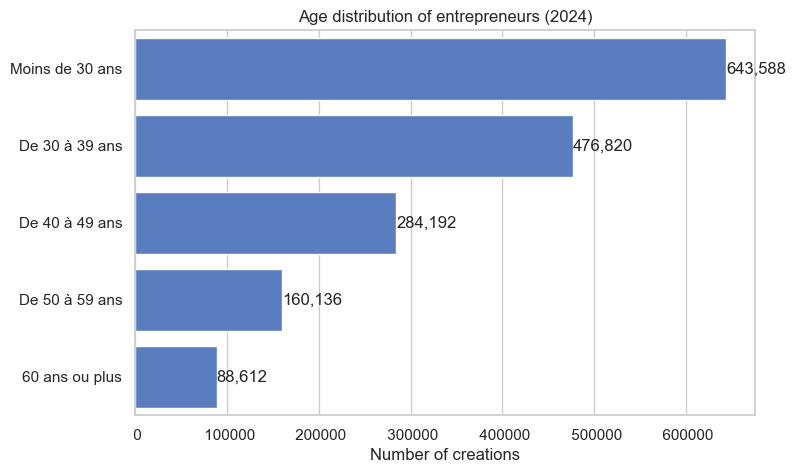

In [91]:
age_data = df[(df["GEO_OBJECT"] == "FRANCE") & (df["SEX"] == "_T") & (df["LEGAL_FORM"] == "_T") & (df["TIME_PERIOD"] == latest_year) & (df["AGE_LABEL"] != "Total")]

age_dist = (age_data.groupby("AGE_LABEL", as_index=False)["OBS_VALUE"].sum()
            .sort_values("OBS_VALUE", ascending=False))


plt.figure(figsize=(8,5))
ax = sns.barplot(data=age_dist, x="OBS_VALUE", y="AGE_LABEL")

for i, v in enumerate(age_dist["OBS_VALUE"]):
    plt.text(v, i, f"{v:,}", va='center')

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x: .0f}"))
plt.title(f"Age distribution of entrepreneurs ({latest_year})")
plt.xlabel("Number of creations")
plt.ylabel("")
plt.show()



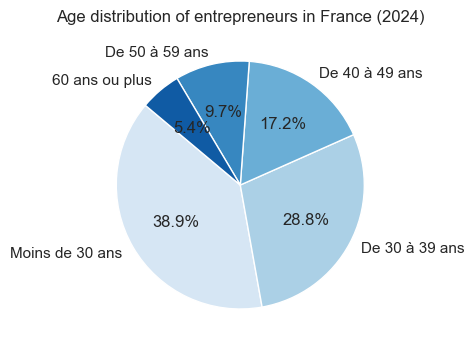

In [92]:
plt.figure(figsize=(4,7))
plt.pie(
    age_dist["OBS_VALUE"],
    labels=age_dist["AGE_LABEL"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Blues", n_colors=len(age_dist))
)

plt.title(f"Age distribution of entrepreneurs in France ({latest_year})")
plt.show()

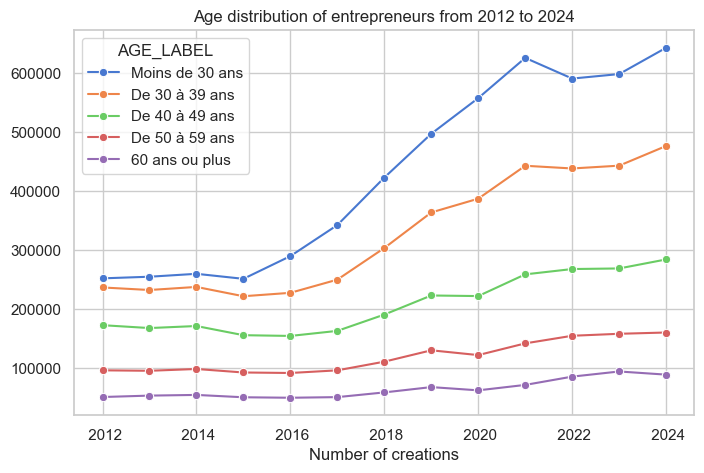

In [99]:
age_data = df[(df["GEO_OBJECT"] == "FRANCE") & (df["SEX"] == "_T") & (df["LEGAL_FORM"] == "_T") & (df["AGE_LABEL"] != "Total")]

age_dist = (age_data.groupby(["TIME_PERIOD", "AGE_LABEL"], as_index=False)["OBS_VALUE"].sum()
            .sort_values("OBS_VALUE", ascending=False))


plt.figure(figsize=(8,5))
ax = sns.lineplot(data=age_dist, x="TIME_PERIOD", y="OBS_VALUE", hue="AGE_LABEL", marker="o")



ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x: .0f}"))
plt.title(f"Age distribution of entrepreneurs from 2012 to 2024")
plt.xlabel("Number of creations")
plt.ylabel("")
plt.show()

## Legal form <a id="legal"></a>

### Legal form distribution over time <a id="legal_dist"></a>

The evolution of legal forms reveals that **micro-entrepreneurs** have become the main driver of business creation in France.  
Their numbers have **grown sharply since 2017**, while the share of individual enterprises outside the micro-entrepreneur regime has remained relatively stable and even sligthly declined.

This trend may suggest that the simplification of administrative procedures and favorable fiscal conditions under the micro-entrepreneur status have lowered barriers to entry, making entrepreneurship more accessible to a wider population.  

The steady growth of this regime could also indicate a broader shift toward flexible, small-scale, and self-managed business models, especially in digital and service-based activities.

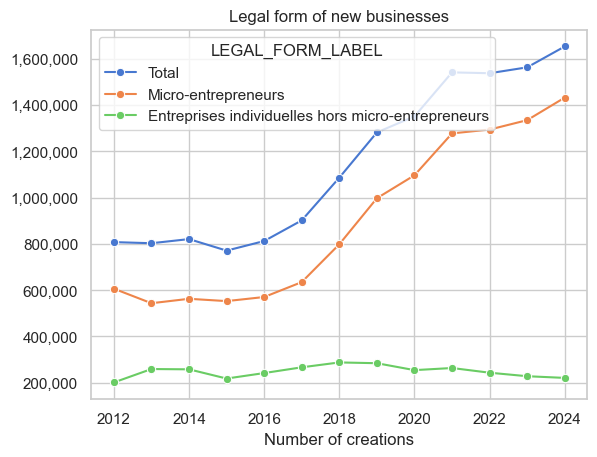

In [104]:
legal_data = data[
    (df["GEO_OBJECT"] == "FRANCE") 
    & (df["SEX"] == "_T") 
    & (df["AGE"] == "_T")]

legal_dist = (legal_data.groupby(["TIME_PERIOD", "LEGAL_FORM_LABEL"], as_index=False)["OBS_VALUE"].sum()
              .sort_values("OBS_VALUE", ascending=False))

sns.lineplot(data=legal_dist, x="TIME_PERIOD", y="OBS_VALUE", hue="LEGAL_FORM_LABEL", marker ='o')

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.title(f"Legal form of new businesses")
plt.xlabel("Number of creations")
plt.ylabel("")
plt.show()

